In [1]:
!pip install tensorflow openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

In [7]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [8]:
data_folder   = r"/content"
output_folder = r"/content"

os.makedirs(output_folder, exist_ok=True)

files = glob.glob(os.path.join(data_folder, "RevenueCenter_*.xlsx"))

In [9]:
# Error matrix
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

In [10]:
def create_sequences(series, window=30):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)


Processing: RevenueCenter_5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.2154 - val_loss: 0.1893
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0392 - val_loss: 0.0347
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0127 - val_loss: 0.0236
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0102 - val_loss: 0.0159
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0106 - val_loss: 0.0264
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0084 - val_loss: 0.0259
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0108 - val_loss: 0.0222
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0092 - val_loss: 0.0258
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0066 - val_loss: 0.0289
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0070 - val_loss: 0.0233
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0091 - val_loss: 0.0260
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

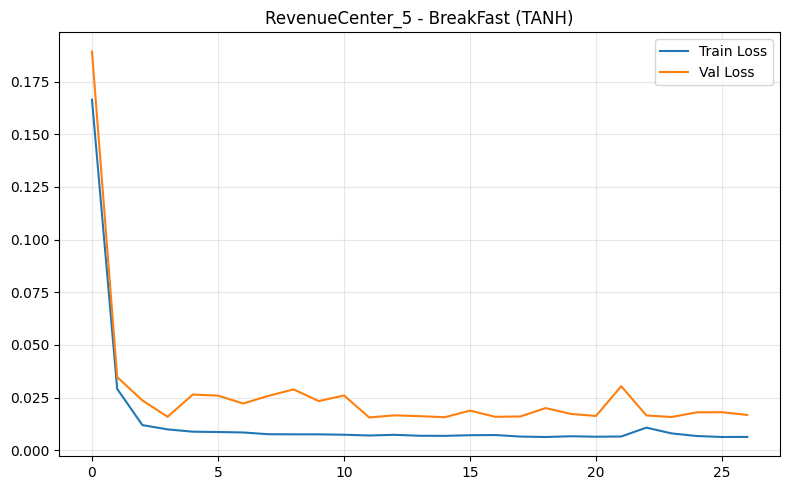

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


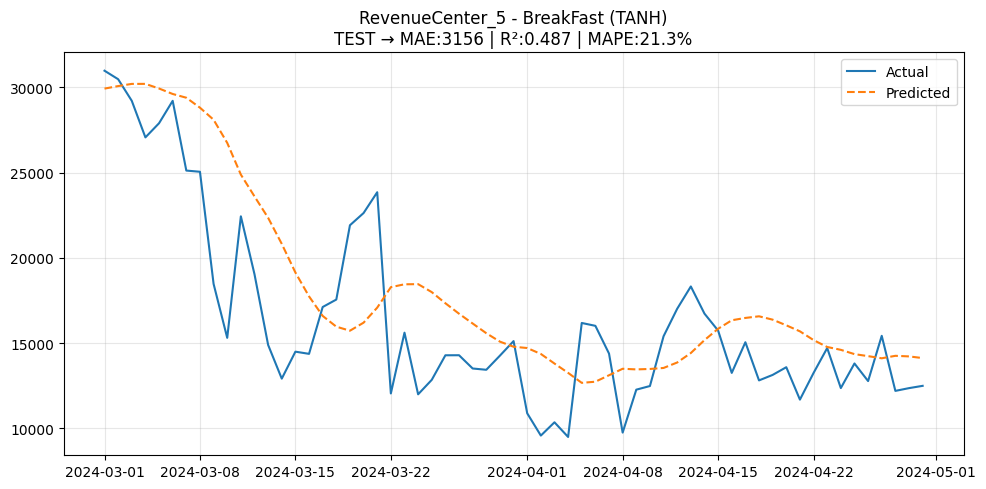

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0120 - val_loss: 0.0192
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0146 - val_loss: 0.0170
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0159 - val_loss: 0.0222
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0210 - val_loss: 0.0221
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0135 - val_loss: 0.0160
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0154 - val_loss: 0.0194
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0121 - val_loss: 0.0166
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0131 - val_loss: 0.0180
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0122 - val_loss: 0.0164
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0140 - val_loss: 0.0179
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0150 - val_loss: 0.0179
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

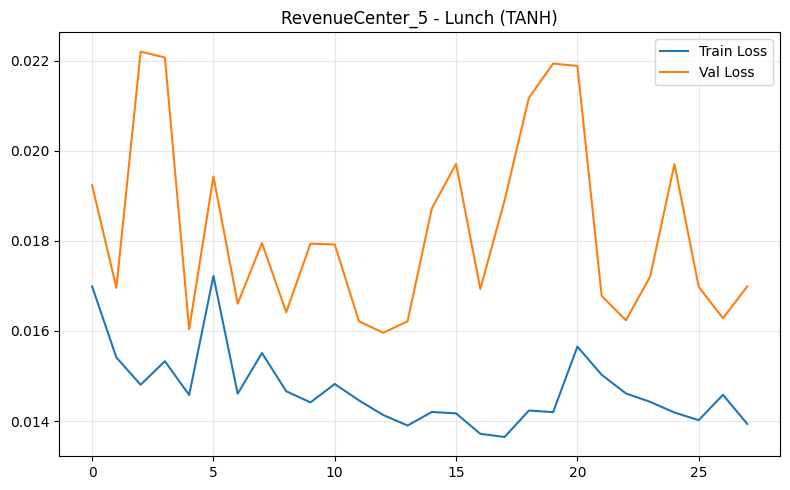

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


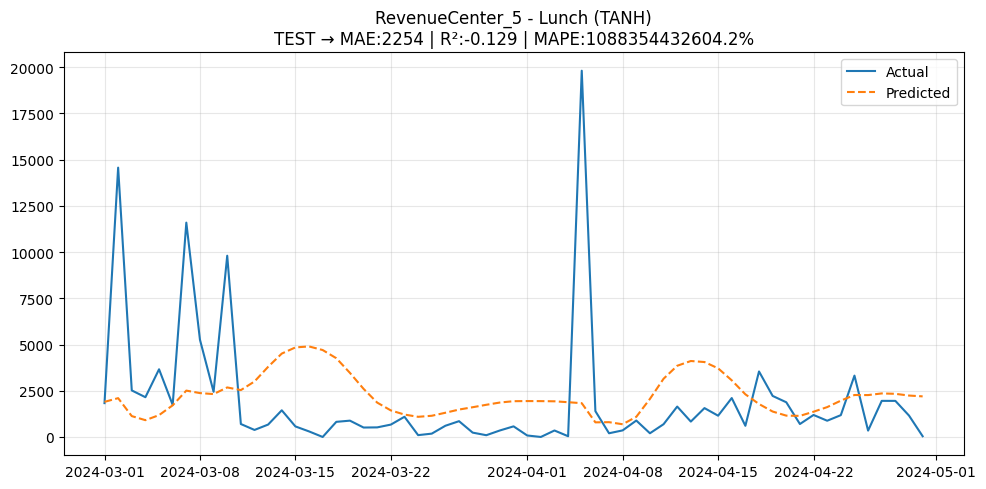

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0397 - val_loss: 0.0557
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0192 - val_loss: 0.0550
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0199 - val_loss: 0.0628
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0215 - val_loss: 0.0722
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0224 - val_loss: 0.0599
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0194 - val_loss: 0.0606
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0217 - val_loss: 0.0588
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0199 - val_loss: 0.0706
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0154 - val_loss: 0.0740
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0226 - val_loss: 0.0690
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0174 - val_loss: 0.0766
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

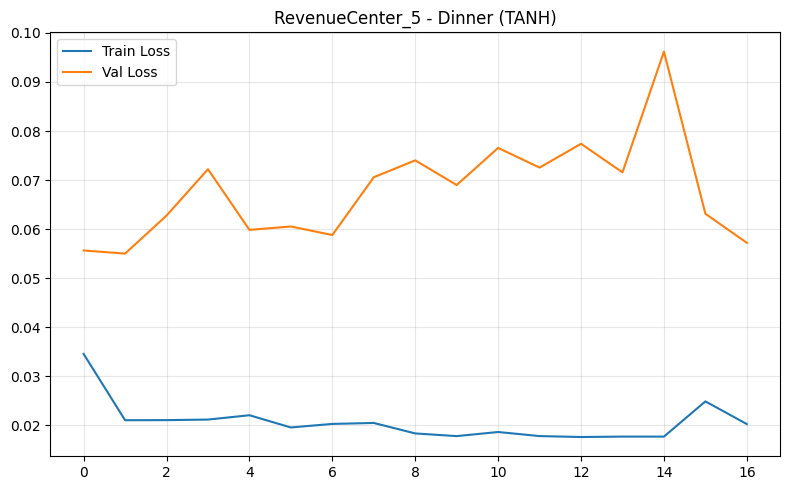

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


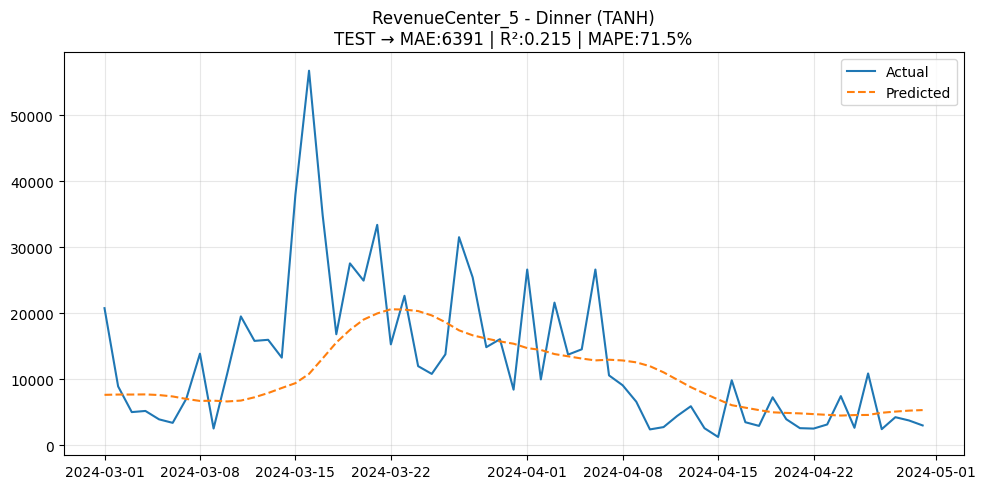

Saved: /content/RevenueCenter_5

Processing: RevenueCenter_7


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0106 - val_loss: 0.0047
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0086 - val_loss: 0.0048
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0083 - val_loss: 0.0046
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0100 - val_loss: 0.0046
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0094 - val_loss: 0.0044
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0078 - val_loss: 0.0044
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0078 - val_loss: 0.0043
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0099 - val_loss: 0.0045
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0083 - val_loss: 0.0044
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0112 - val_loss: 0.0045
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0077 - val_loss: 0.0045
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step

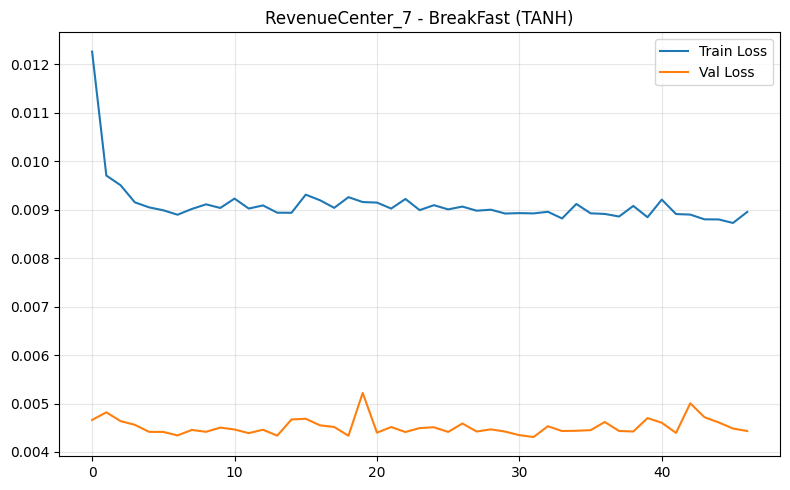

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


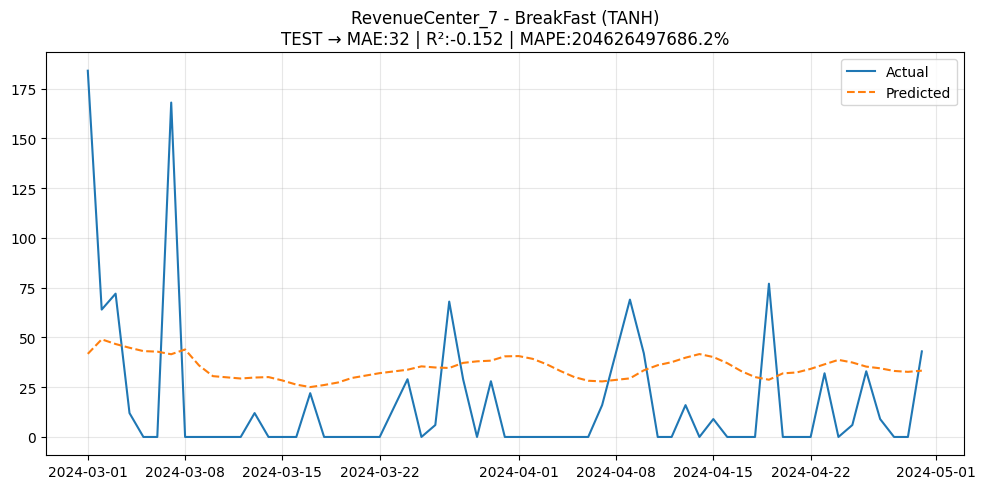

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0175 - val_loss: 0.0424
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0122 - val_loss: 0.0433
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0113 - val_loss: 0.0426
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0095 - val_loss: 0.0399
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0100 - val_loss: 0.0417
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0103 - val_loss: 0.0407
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0101 - val_loss: 0.0404
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0117 - val_loss: 0.0412
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0132 - val_loss: 0.0409
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0113 - val_loss: 0.0408
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0103 - val_loss: 0.0409
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

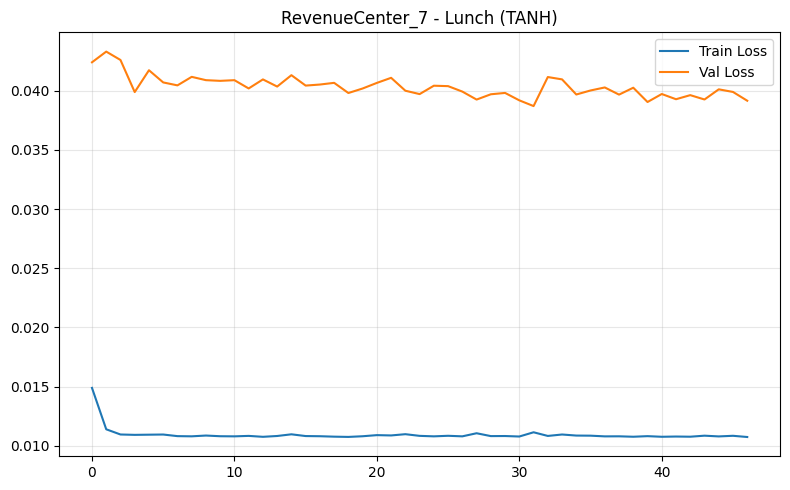

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


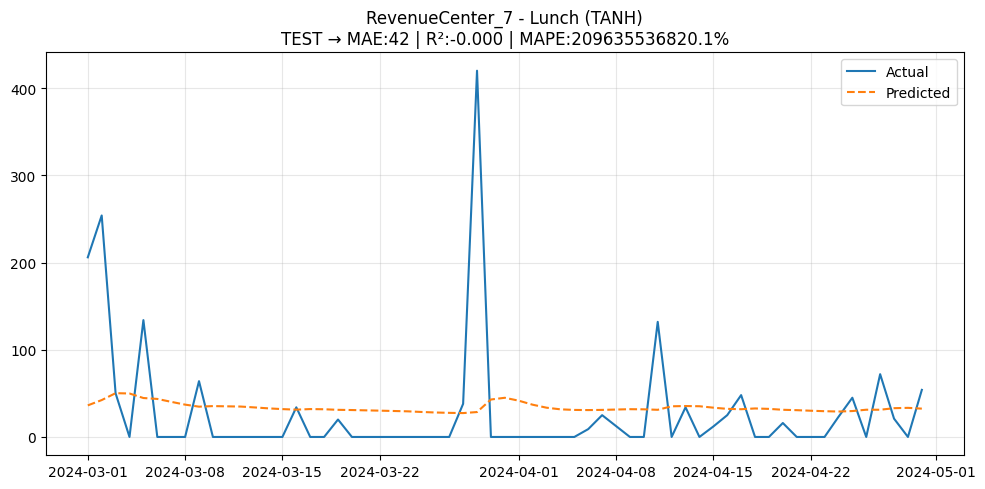

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0242 - val_loss: 0.0722
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0181 - val_loss: 0.0827
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0194 - val_loss: 0.0726
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0167 - val_loss: 0.0702
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0184 - val_loss: 0.0838
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0193 - val_loss: 0.0794
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0205 - val_loss: 0.0897
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0193 - val_loss: 0.0928
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0212 - val_loss: 0.0829
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0175 - val_loss: 0.0758
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0195 - val_loss: 0.0790
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

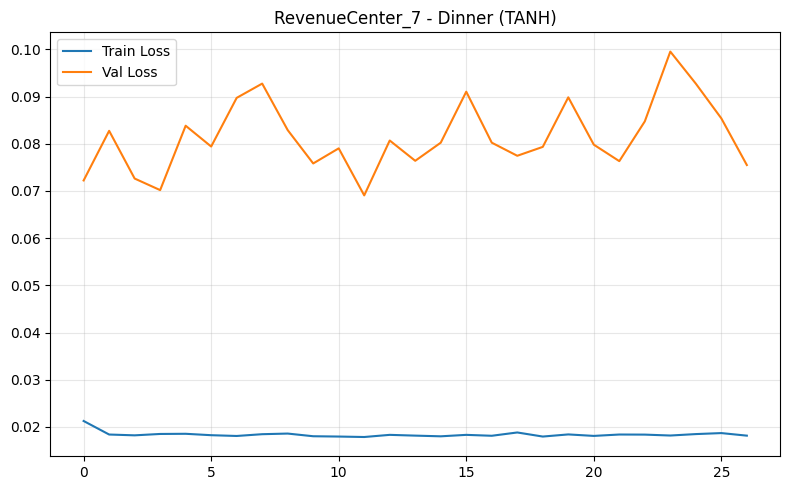

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


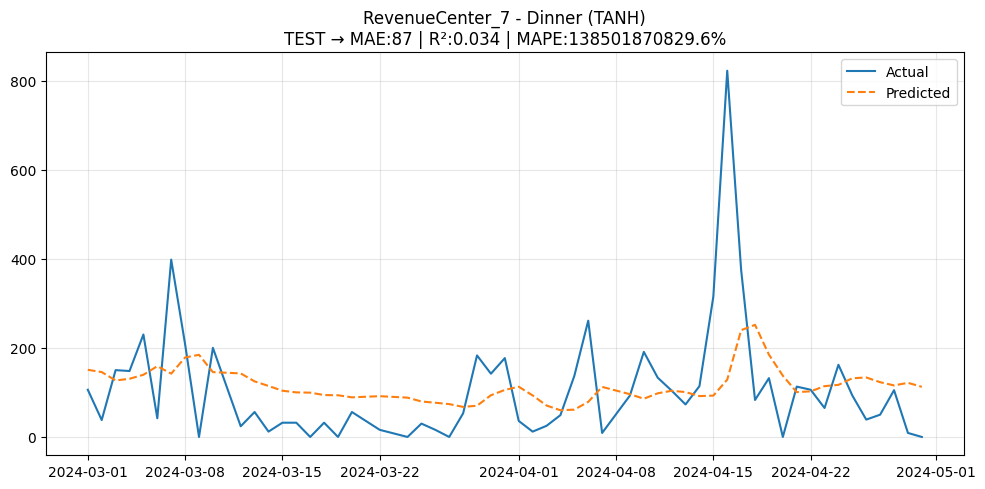

Saved: /content/RevenueCenter_7

Processing: RevenueCenter_2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0276 - val_loss: 0.0206
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0157 - val_loss: 0.0221
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0159 - val_loss: 0.0285
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0177 - val_loss: 0.0262
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0145 - val_loss: 0.0234
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0151 - val_loss: 0.0278
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0164 - val_loss: 0.0246
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0202 - val_loss: 0.0275
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0201 - val_loss: 0.0281
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0175 - val_loss: 0.0241
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0149 - val_loss: 0.0255
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step

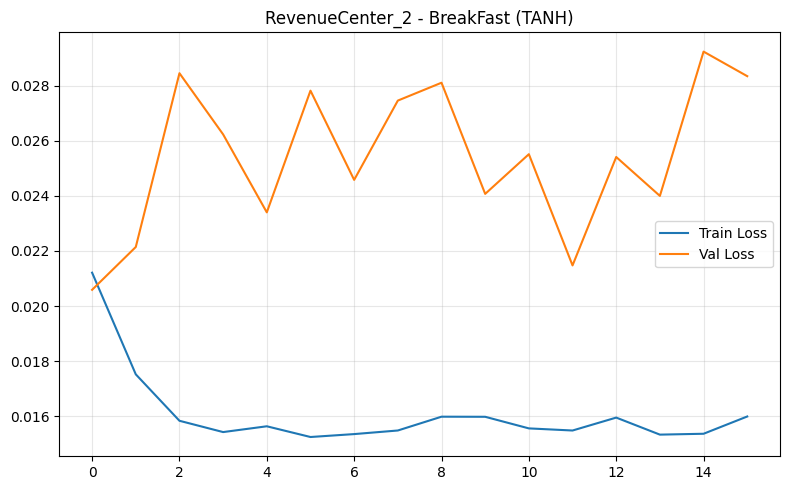

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


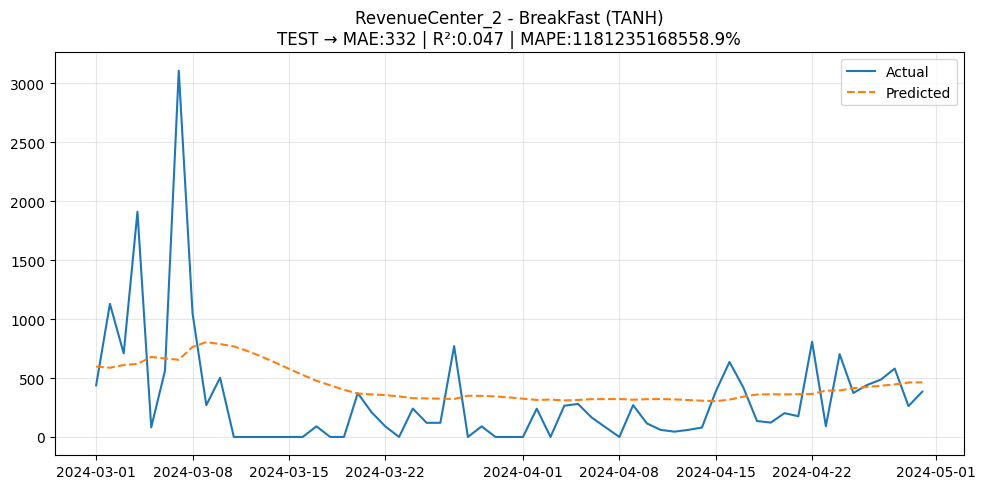

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0224 - val_loss: 0.0577
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0205 - val_loss: 0.0715
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0248 - val_loss: 0.0657
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0160 - val_loss: 0.0770
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0230 - val_loss: 0.0694
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0187 - val_loss: 0.0875
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0161 - val_loss: 0.0593
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0152 - val_loss: 0.0683
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0143 - val_loss: 0.0660
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0163 - val_loss: 0.0644
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0159 - val_loss: 0.0607
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step

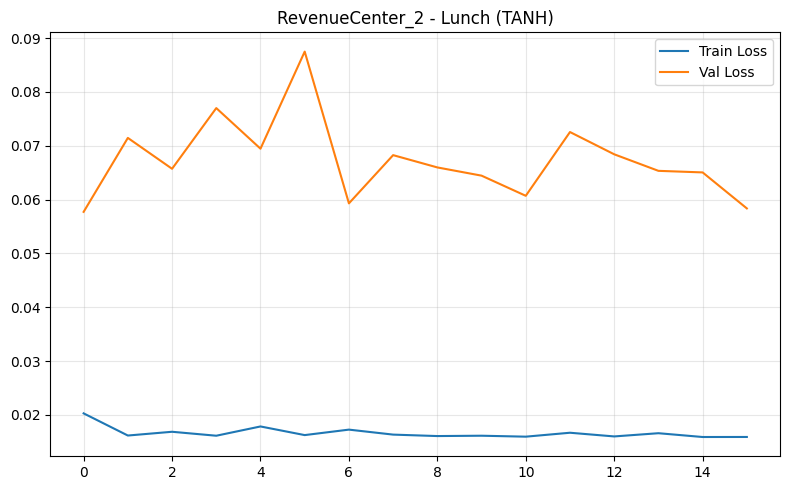

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


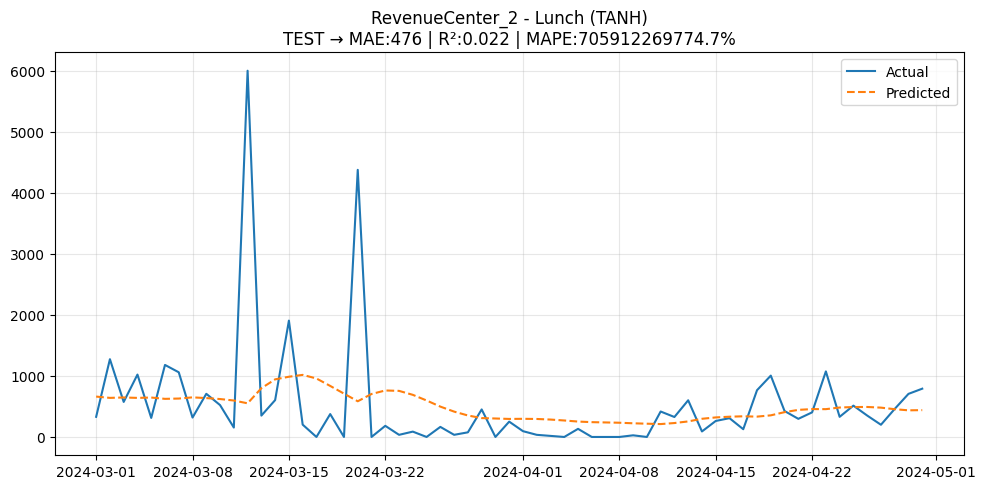

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0028 - val_loss: 0.0268
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0026 - val_loss: 0.0317
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0021 - val_loss: 0.0286
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0015 - val_loss: 0.0273
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0023 - val_loss: 0.0294
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0020 - val_loss: 0.0294
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0017 - val_loss: 0.0265
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0024 - val_loss: 0.0288
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0017 - val_loss: 0.0279
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0020 - val_loss: 0.0287
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0026 - val_loss: 0.0281
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step

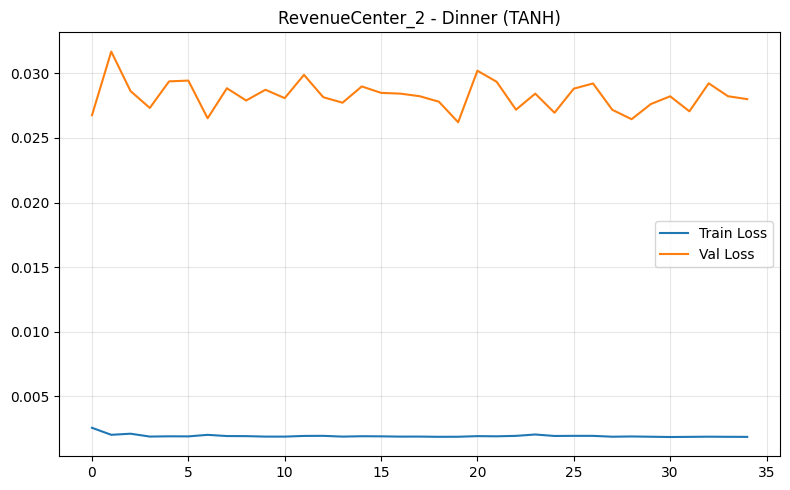

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


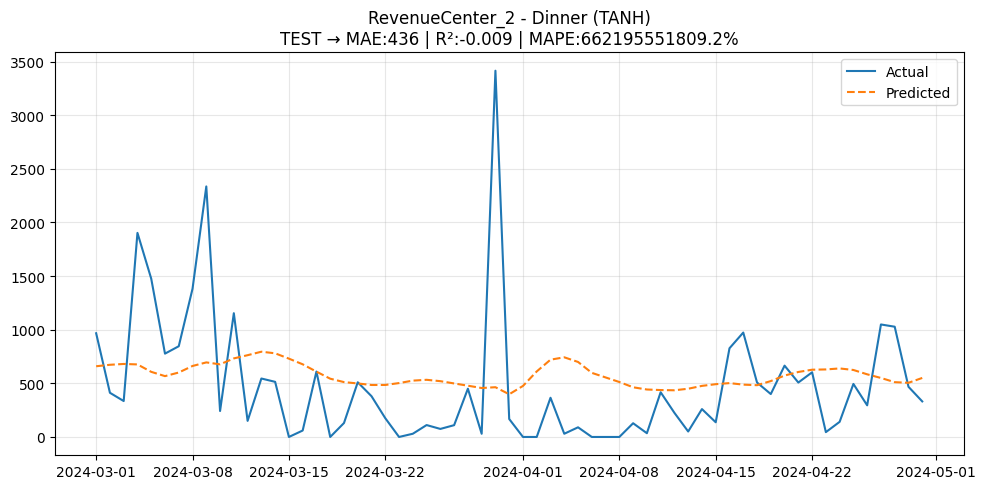

Saved: /content/RevenueCenter_2

Processing: RevenueCenter_1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0190 - val_loss: 0.0504
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0051 - val_loss: 0.0374
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0071 - val_loss: 0.0306
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0047 - val_loss: 0.0287
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0052 - val_loss: 0.0289
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0043 - val_loss: 0.0297
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0044 - val_loss: 0.0307
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0063 - val_loss: 0.0310
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0045 - val_loss: 0.0309
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0052 - val_loss: 0.0291
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0056 - val_loss: 0.0282
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

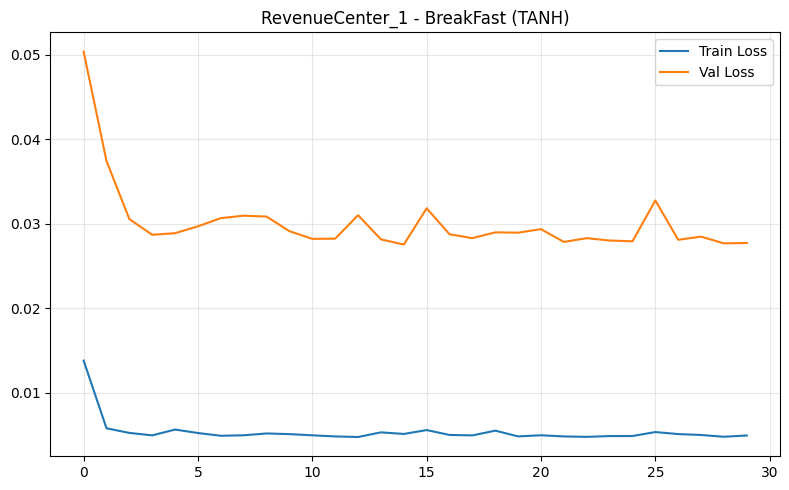

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


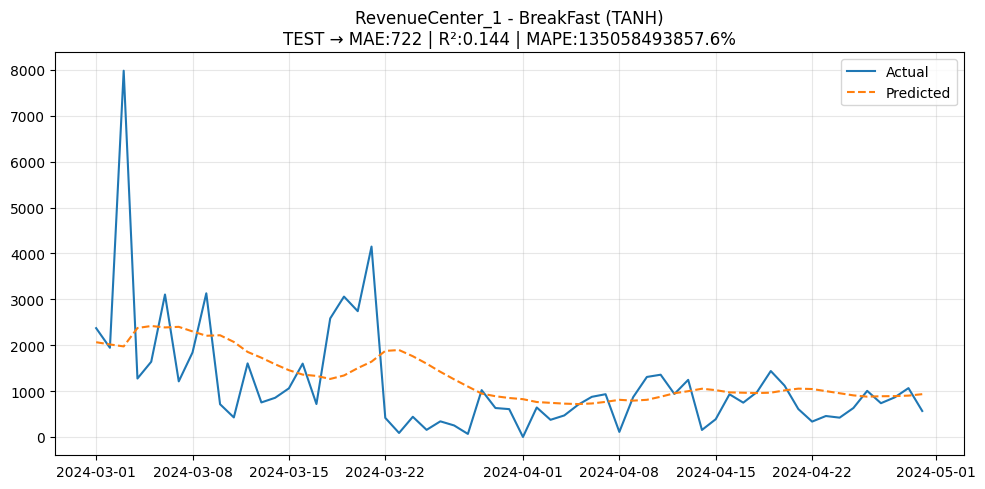

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0501 - val_loss: 0.0758
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0134 - val_loss: 0.0692
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0116 - val_loss: 0.0624
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0139 - val_loss: 0.0742
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0138 - val_loss: 0.0763
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0108 - val_loss: 0.0619
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0124 - val_loss: 0.0602
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0130 - val_loss: 0.0721
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0096 - val_loss: 0.0704
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0117 - val_loss: 0.0653
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0089 - val_loss: 0.0614
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

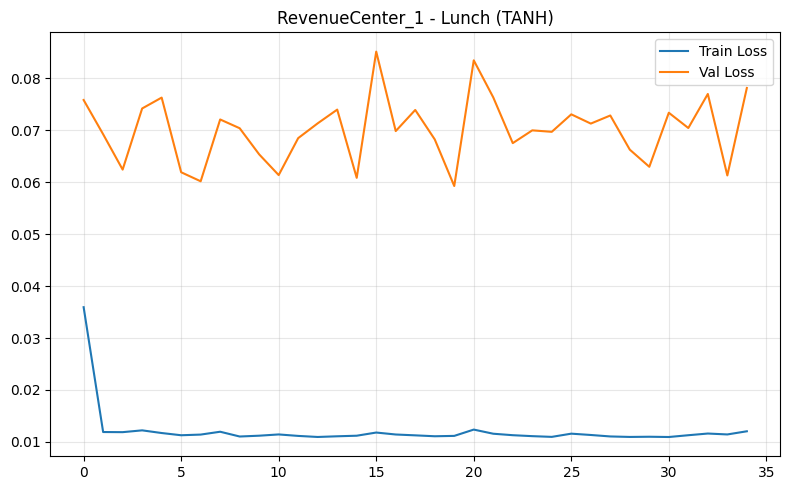

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


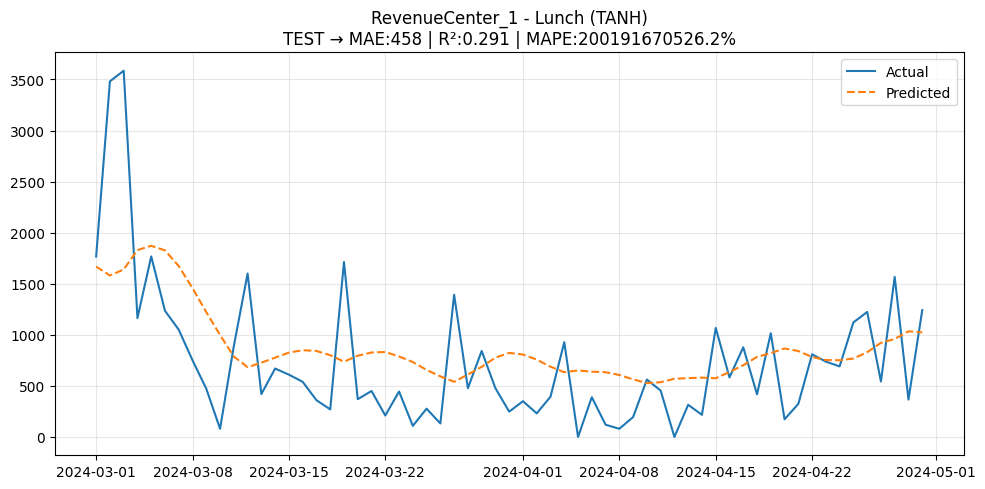

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0993 - val_loss: 0.0257
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0152 - val_loss: 0.0742
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0142 - val_loss: 0.0390
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0130 - val_loss: 0.0294
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0135 - val_loss: 0.0265
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0147 - val_loss: 0.0283
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0123 - val_loss: 0.0441
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0130 - val_loss: 0.0261
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0124 - val_loss: 0.0294
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0139 - val_loss: 0.0323
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0120 - val_loss: 0.0318
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

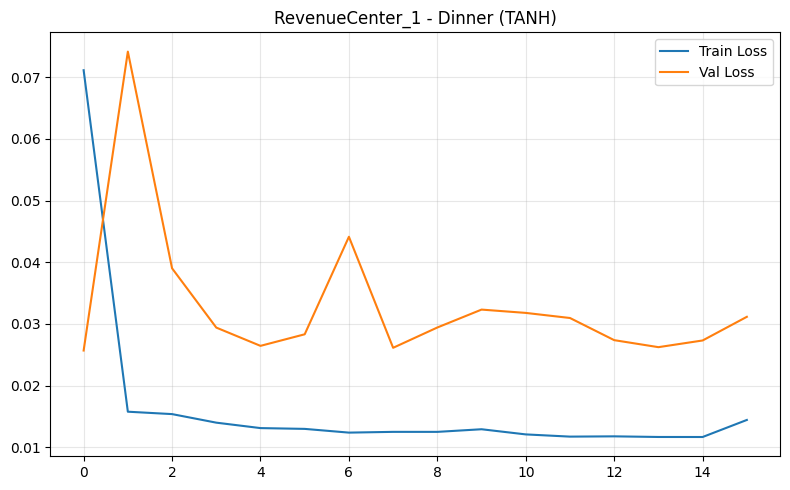

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


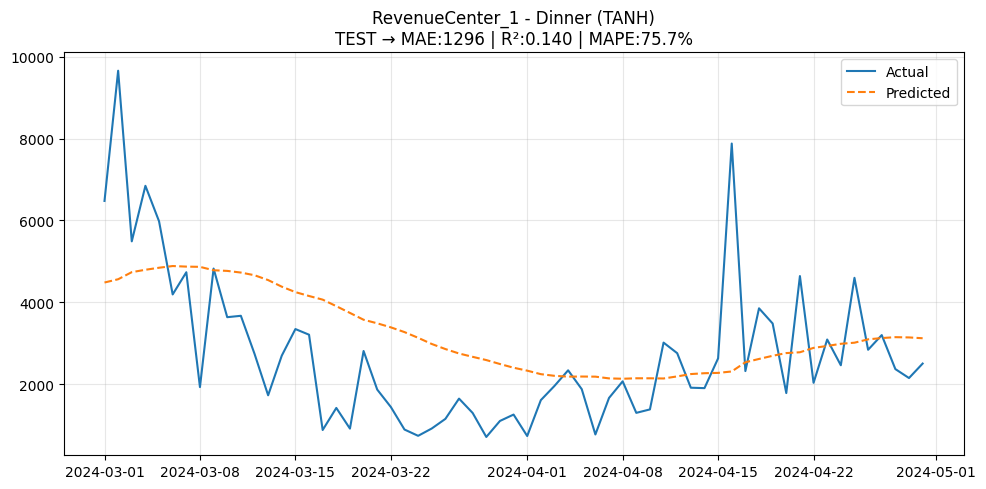

Saved: /content/RevenueCenter_1

Processing: RevenueCenter_6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.0251 - val_loss: 0.0501
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0219 - val_loss: 0.0509
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0246 - val_loss: 0.0507
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0242 - val_loss: 0.0502
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0253 - val_loss: 0.0518
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0250 - val_loss: 0.0506
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0231 - val_loss: 0.0510
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0241 - val_loss: 0.0505
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0194 - val_loss: 0.0499
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0230 - val_loss: 0.0496
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0314 - val_loss: 0.0491
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

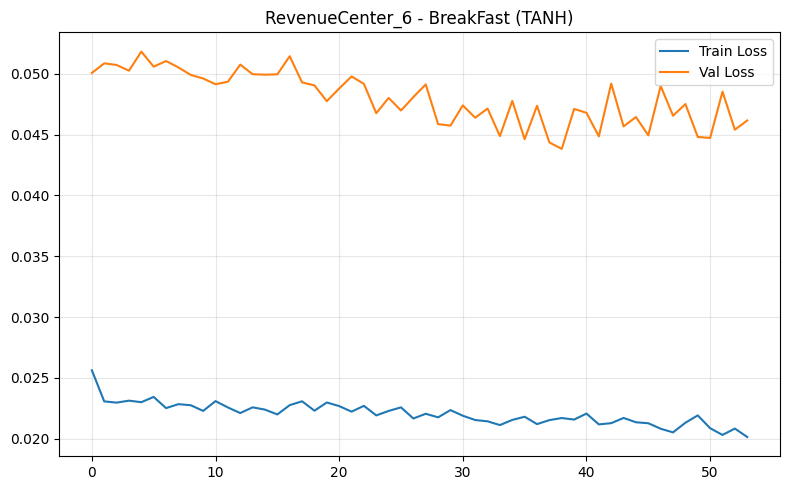

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


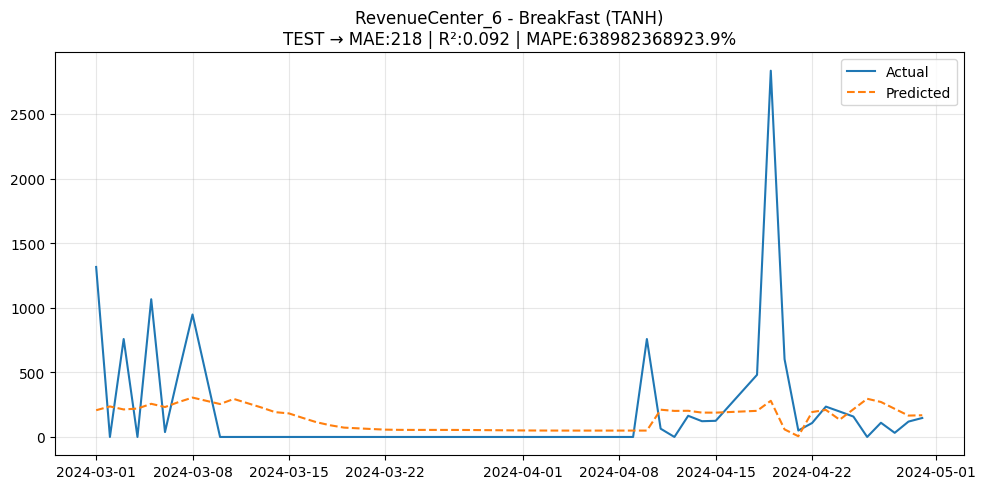

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0153 - val_loss: 0.0189
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0109 - val_loss: 0.0192
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0098 - val_loss: 0.0217
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0100 - val_loss: 0.0235
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0108 - val_loss: 0.0190
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0091 - val_loss: 0.0205
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0096 - val_loss: 0.0236
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0122 - val_loss: 0.0228
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0120 - val_loss: 0.0196
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0096 - val_loss: 0.0211
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0113 - val_loss: 0.0194
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

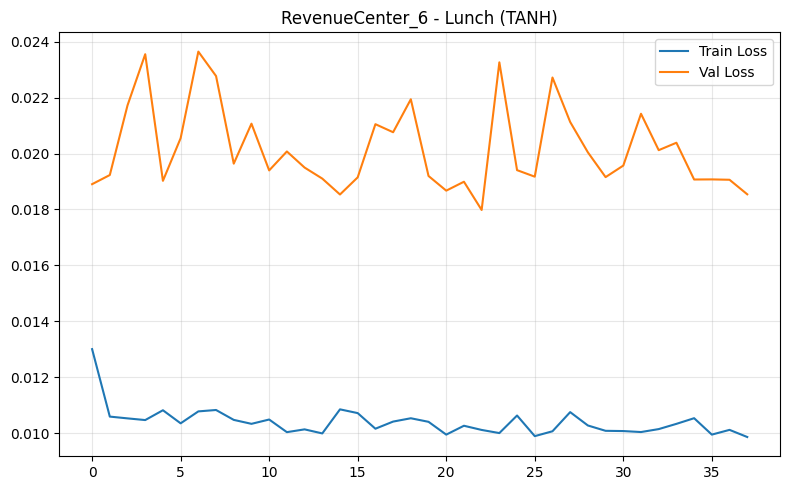

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


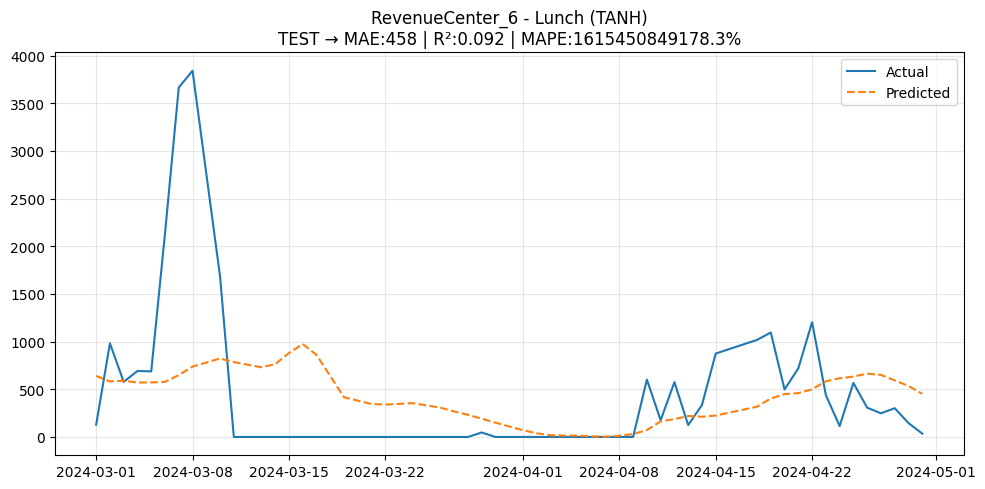

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0016 - val_loss: 0.0253
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0047 - val_loss: 0.0253
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0024 - val_loss: 0.0248
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0054 - val_loss: 0.0251
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0052 - val_loss: 0.0251
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0034 - val_loss: 0.0248
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0032 - val_loss: 0.0249
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0048 - val_loss: 0.0248
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0033 - val_loss: 0.0250
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0040 - val_loss: 0.0248
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0041 - val_loss: 0.0251
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

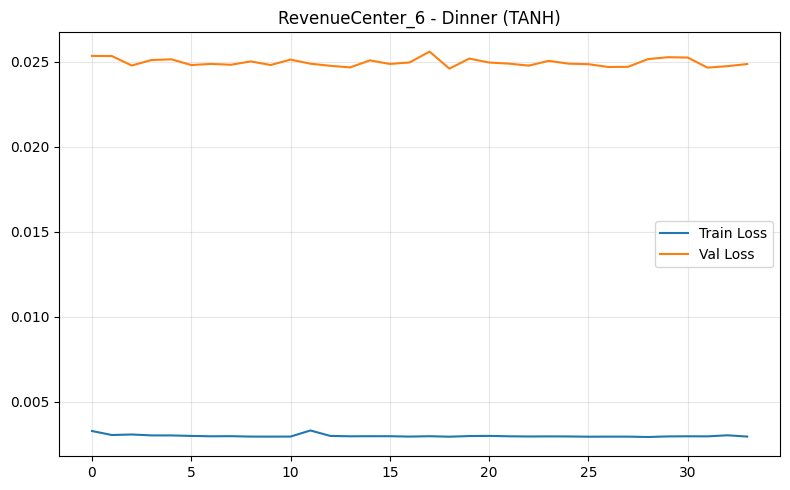

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


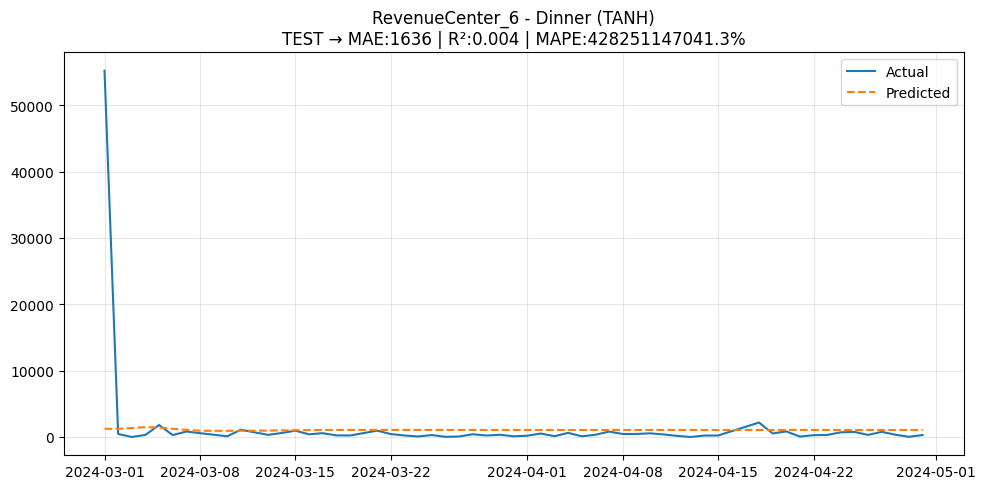

Saved: /content/RevenueCenter_6

Processing: RevenueCenter_4
Skipping RevenueCenter_4 - BreakFast (constant values)
Skipping RevenueCenter_4 - Lunch (constant values)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0015 - val_loss: 1.9623e-04
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 8.0709e-04 - val_loss: 2.0920e-04
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 8.2876e-04 - val_loss: 1.3054e-04
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0034 - val_loss: 4.3010e-07
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0055 - val_loss: 1.3544e-06
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0043 - val_loss: 9.8581e-09
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0022 - val_loss: 4.0684e-05
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 7.5582e-04 - val_loss: 5.0945e-05
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0018 - val_loss: 8.4600e-06
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0017 - val_loss: 5.0271e-05
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0033 - val_loss: 2.3202e

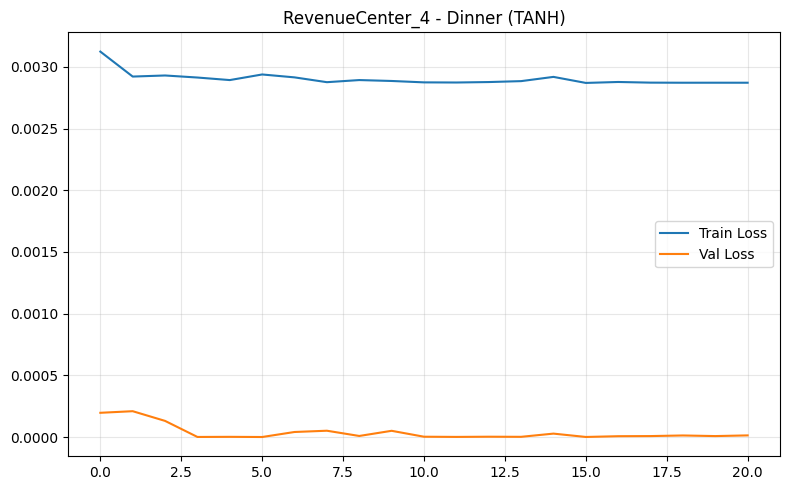

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


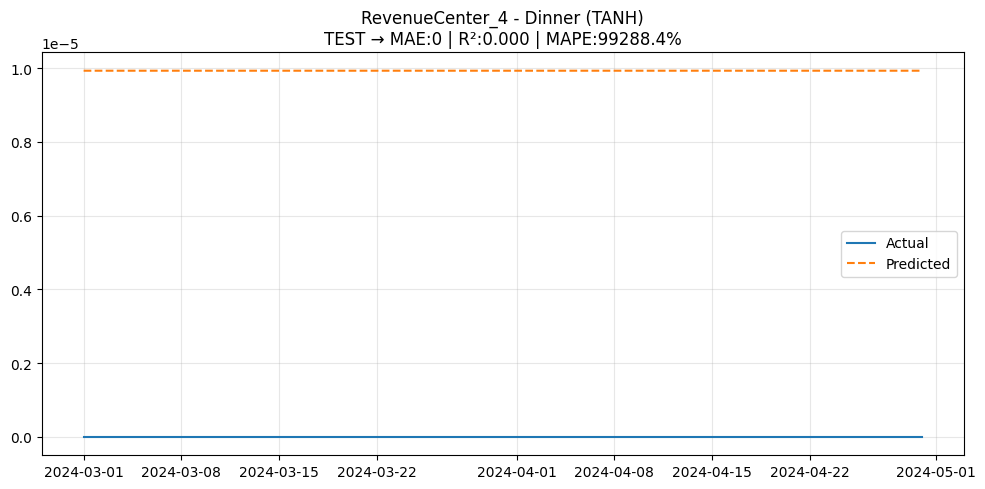

Saved: /content/RevenueCenter_4

Processing: RevenueCenter_8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0138 - val_loss: 0.0029
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0054 - val_loss: 0.0028
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0100 - val_loss: 0.0024
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0080 - val_loss: 0.0023
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0069 - val_loss: 0.0024
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0069 - val_loss: 0.0026
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0146 - val_loss: 0.0023
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0059 - val_loss: 0.0025
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0088 - val_loss: 0.0024
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0153 - val_loss: 0.0024
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0080 - val_loss: 0.0025
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

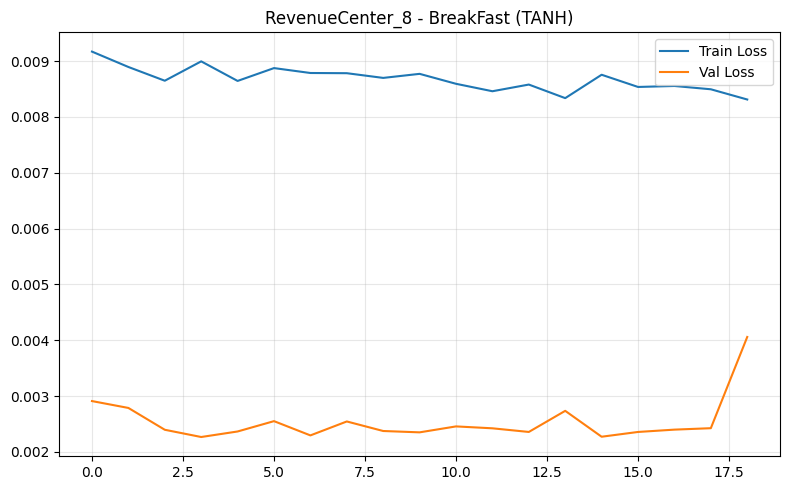

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


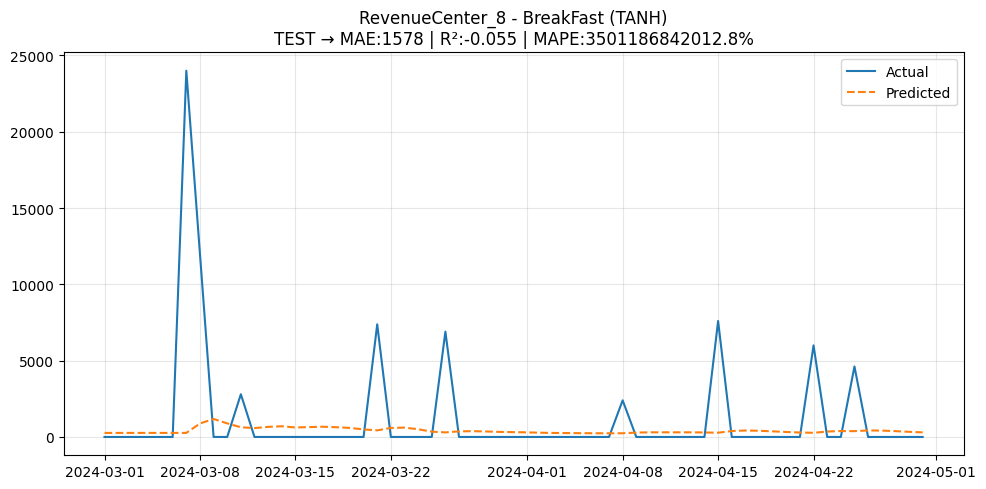

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0129 - val_loss: 0.1057
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0171 - val_loss: 0.1122
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0154 - val_loss: 0.1206
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0193 - val_loss: 0.1062
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0150 - val_loss: 0.0962
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0186 - val_loss: 0.1068
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0168 - val_loss: 0.1028
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0128 - val_loss: 0.0999
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0163 - val_loss: 0.1096
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0116 - val_loss: 0.1086
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0141 - val_loss: 0.1046
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

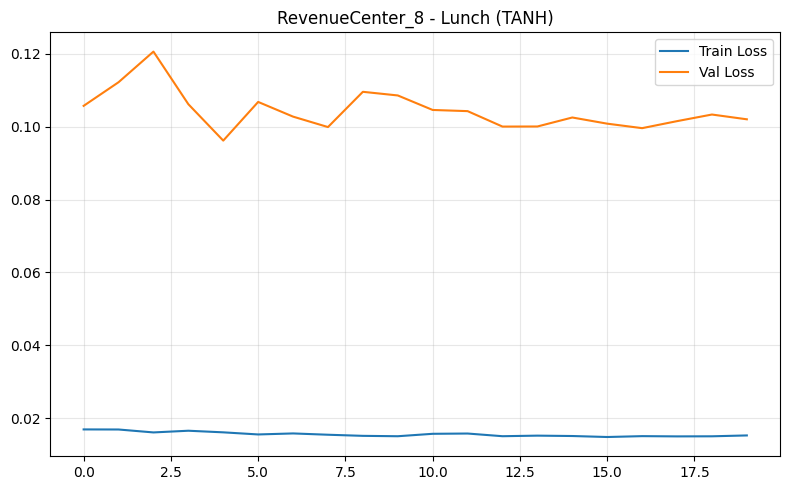

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


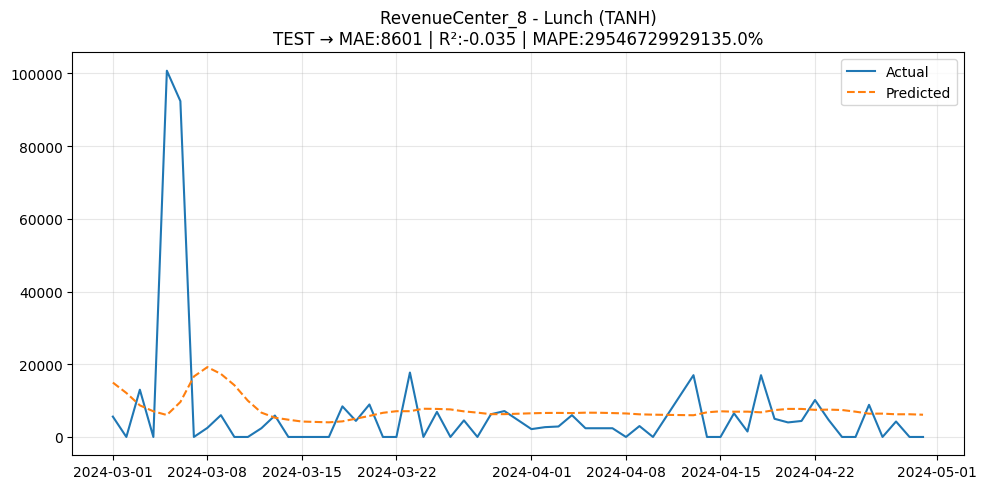

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 0.0428 - val_loss: 0.0508
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0148 - val_loss: 0.0546
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0143 - val_loss: 0.0524
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0128 - val_loss: 0.0660
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0134 - val_loss: 0.0533
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0116 - val_loss: 0.0563
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0120 - val_loss: 0.0539
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0116 - val_loss: 0.0553
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0148 - val_loss: 0.0531
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0144 - val_loss: 0.0516
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0148 - val_loss: 0.0581
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

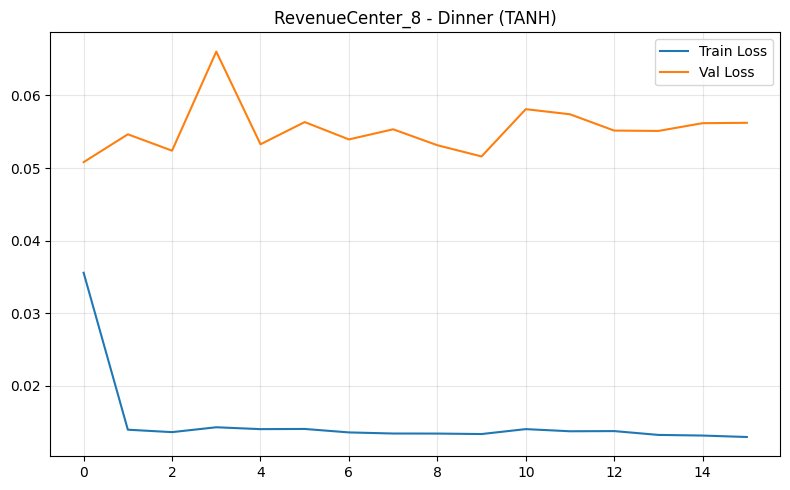

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


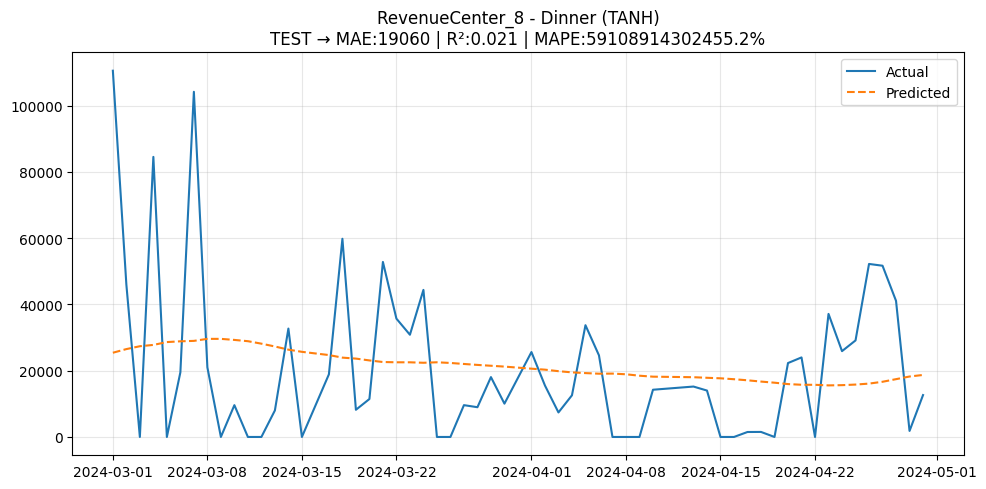

Saved: /content/RevenueCenter_8

Processing: RevenueCenter_3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - loss: 0.0926 - val_loss: 0.0413
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0267 - val_loss: 0.0362
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0257 - val_loss: 0.0423
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0239 - val_loss: 0.0371
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0240 - val_loss: 0.0410
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0183 - val_loss: 0.0357
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0226 - val_loss: 0.0427
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0218 - val_loss: 0.0367
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0213 - val_loss: 0.0383
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0227 - val_loss: 0.0390
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0208 - val_loss: 0.0387
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

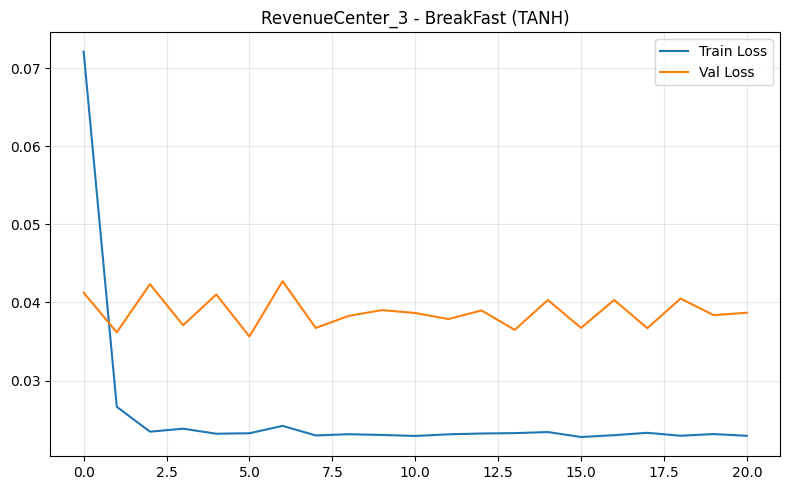

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


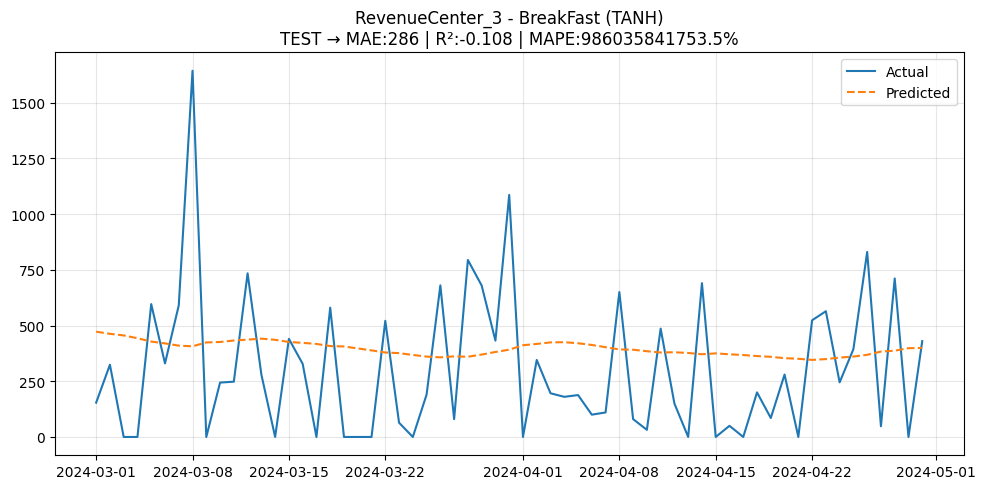

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0196 - val_loss: 0.0470
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0097 - val_loss: 0.0431
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0163 - val_loss: 0.0580
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0103 - val_loss: 0.0627
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0112 - val_loss: 0.0644
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0094 - val_loss: 0.0516
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0113 - val_loss: 0.0640
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0096 - val_loss: 0.0572
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0094 - val_loss: 0.0593
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0097 - val_loss: 0.0553
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0099 - val_loss: 0.0556
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

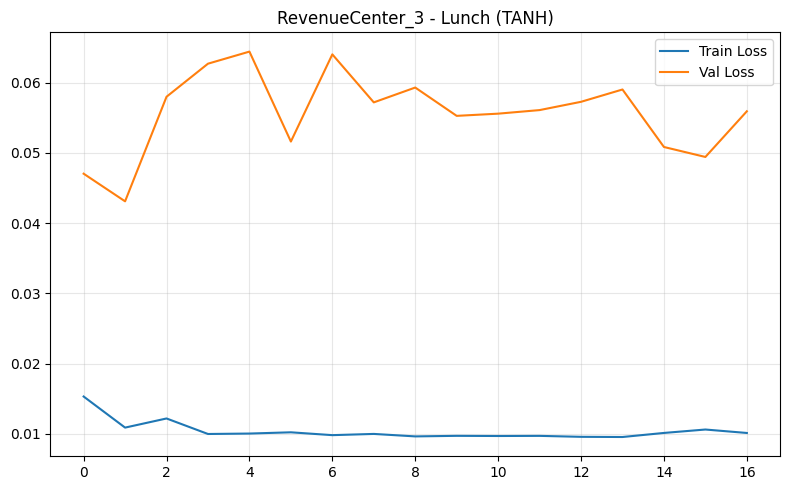

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


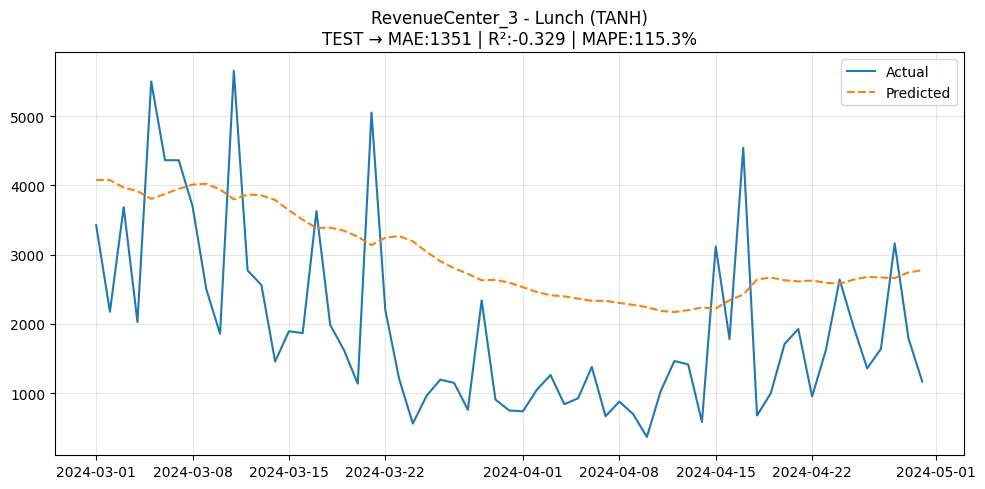

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.1485 - val_loss: 0.0315
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0153 - val_loss: 0.0988
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0121 - val_loss: 0.0633
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0090 - val_loss: 0.0471
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0103 - val_loss: 0.0555
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0093 - val_loss: 0.0367
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0094 - val_loss: 0.0480
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0099 - val_loss: 0.0367
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0119 - val_loss: 0.0343
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0100 - val_loss: 0.0310
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0106 - val_loss: 0.0270
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

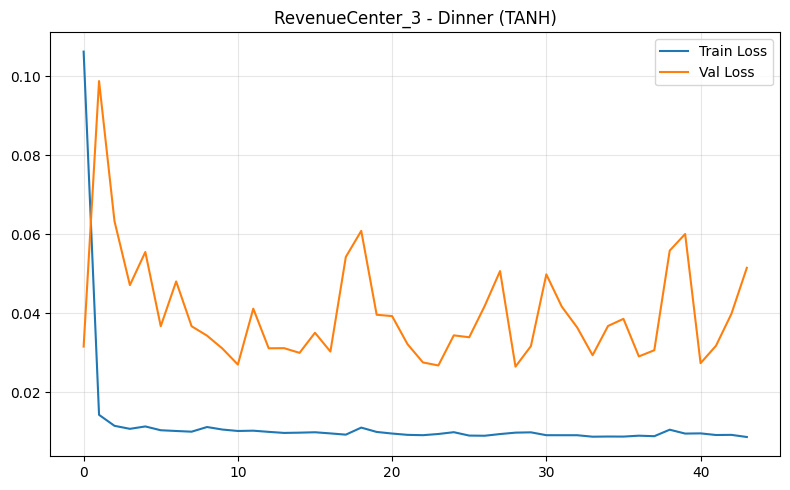

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


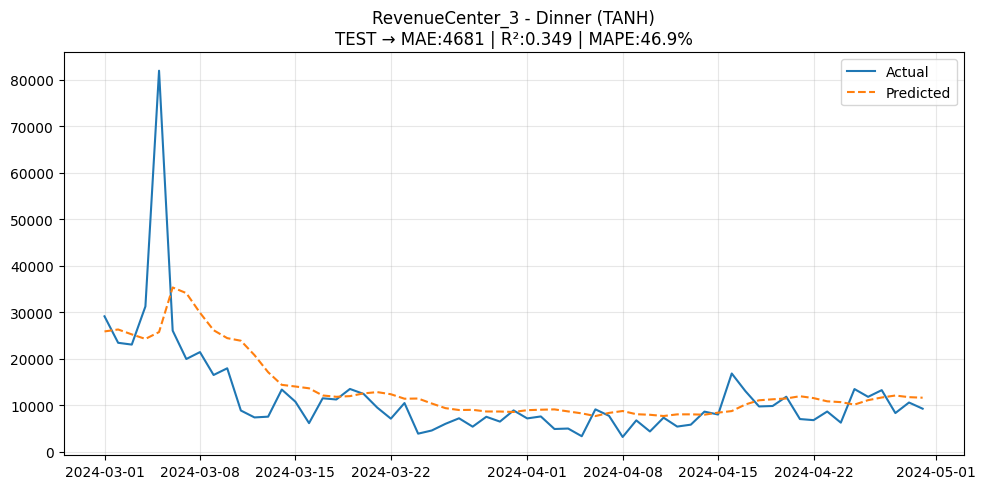

Saved: /content/RevenueCenter_3

Processing: RevenueCenter_9


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0177 - val_loss: 0.0634
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0089 - val_loss: 0.0782
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0094 - val_loss: 0.0892
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0075 - val_loss: 0.0732
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0088 - val_loss: 0.0651
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0075 - val_loss: 0.0693
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0069 - val_loss: 0.0650
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0083 - val_loss: 0.0866
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0102 - val_loss: 0.0748
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0076 - val_loss: 0.0739
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0067 - val_loss: 0.0790
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

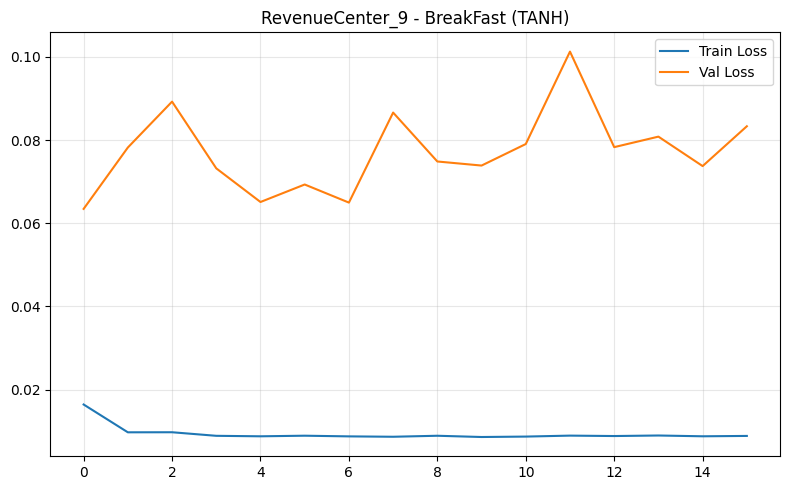

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


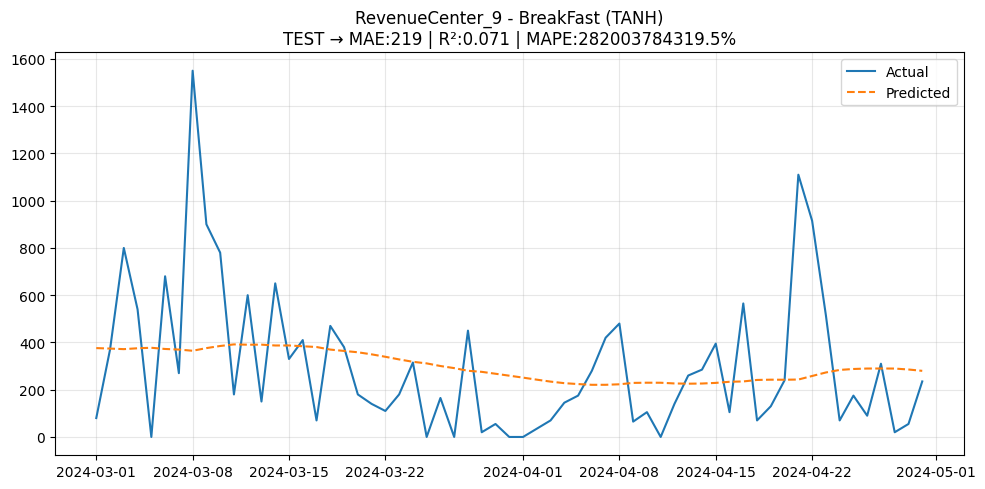

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0.2283 - val_loss: 0.0609
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0331 - val_loss: 0.0610
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0322 - val_loss: 0.0470
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0334 - val_loss: 0.0494
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0318 - val_loss: 0.0478
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0277 - val_loss: 0.0472
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0341 - val_loss: 0.0485
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0320 - val_loss: 0.0472
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0298 - val_loss: 0.0482
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0316 - val_loss: 0.0475
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0310 - val_loss: 0.0478
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

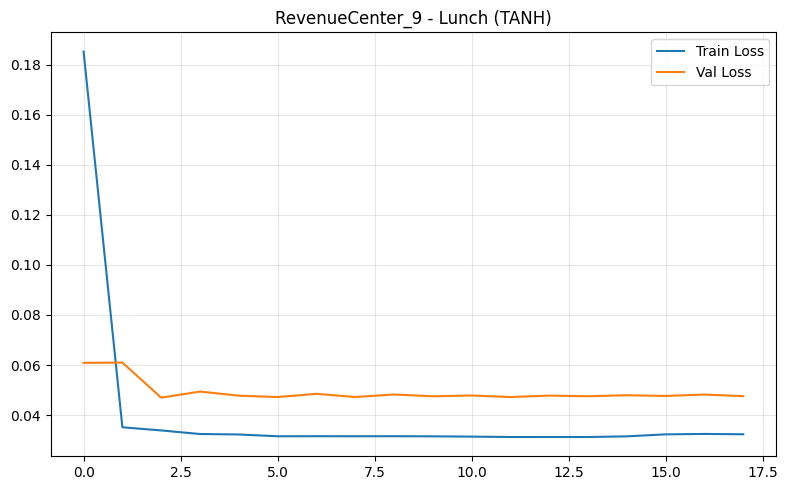

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


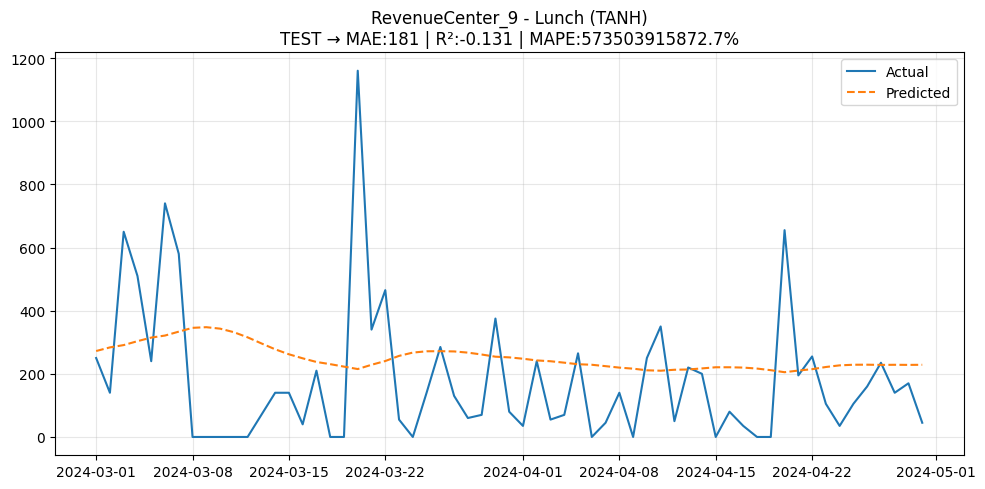

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0260 - val_loss: 0.0141
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0289 - val_loss: 0.0136
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0176 - val_loss: 0.0146
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0216 - val_loss: 0.0140
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0143 - val_loss: 0.0175
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0184 - val_loss: 0.0158
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0190 - val_loss: 0.0149
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0224 - val_loss: 0.0148
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0247 - val_loss: 0.0152
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0249 - val_loss: 0.0149
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0197 - val_loss: 0.0166
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

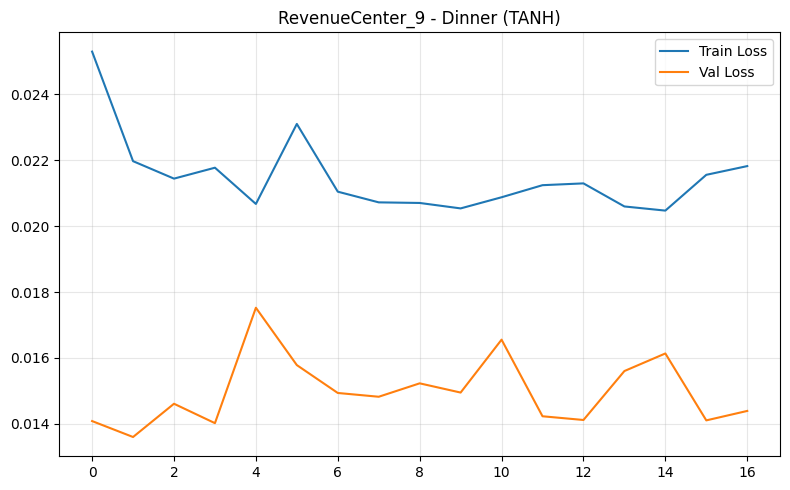

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


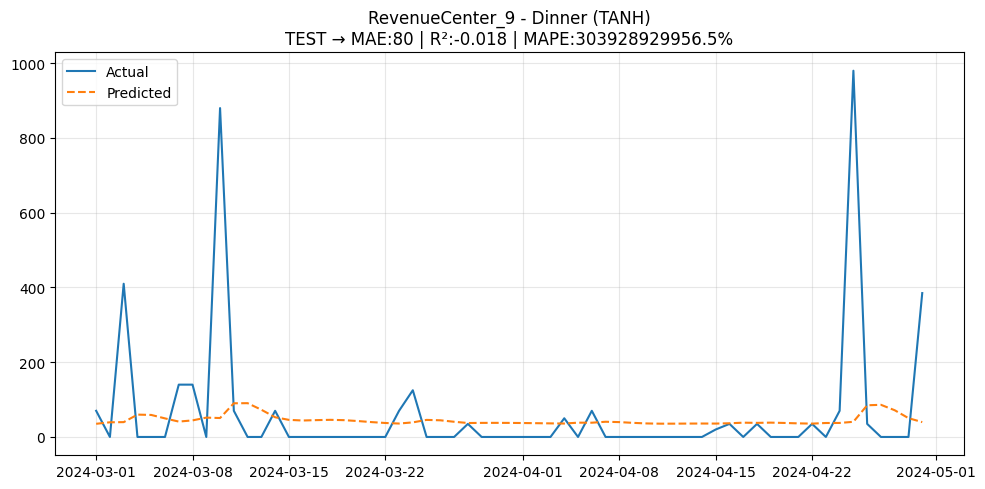

Saved: /content/RevenueCenter_9

ALL CENTERS COMPLETED — TANH MODEL


In [20]:
for file in files:

    center_name = os.path.basename(file).replace(".xlsx", "")
    print("\nProcessing:", center_name)

    center_path = os.path.join(output_folder, center_name)
    os.makedirs(center_path, exist_ok=True)

    df = pd.read_excel(file)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    split_date = df["Date"].max() - pd.DateOffset(months=2)
    meals = ["BreakFast", "Lunch", "Dinner"]

    for meal in meals:

        temp_df = df[["Date", meal]].copy()
        temp_df.rename(columns={meal: "y"}, inplace=True)

        train_df = temp_df[temp_df["Date"] <= split_date]
        test_df  = temp_df[temp_df["Date"] > split_date]

        if train_df["y"].nunique() <= 1:
            print(f"Skipping {center_name} - {meal} (constant values)")
            continue

        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_df[["y"]])
        test_scaled  = scaler.transform(test_df[["y"]])

        WINDOW = 30
        X_train, y_train = create_sequences(train_scaled, WINDOW)
        combined = np.vstack([train_scaled[-WINDOW:], test_scaled])
        X_test, y_test = create_sequences(combined, WINDOW)

        X_train = X_train.reshape(-1, WINDOW, 1)
        X_test  = X_test.reshape(-1, WINDOW, 1)

        # =========================
        # MODEL — TANH
        # =========================
        model = Sequential([

            LSTM(
                1024,
                activation="tanh",
                return_sequences=True,
                input_shape=(WINDOW, 1)
            ),

            LSTM(
                512,
                activation="tanh",
                return_sequences=False
            ),

            Dense(32, activation="relu"),
            Dense(1)
        ])

        model.compile(optimizer="adam", loss="mse")

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            epochs=200,
            batch_size=32,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=1
        )

        # =========================
        # LOSS PLOT
        # =========================
        plt.figure(figsize=(8,5))
        plt.plot(history.history["loss"], label="Train Loss")
        plt.plot(history.history["val_loss"], label="Val Loss")
        plt.title(f"{center_name} - {meal} (TANH)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_loss_tanh.png"), dpi=300)
        plt.show()
        plt.close()

        # =========================
        # PREDICTIONS
        # =========================
        y_train_pred = scaler.inverse_transform(model.predict(X_train))
        y_test_pred  = scaler.inverse_transform(model.predict(X_test))
        y_train_true = scaler.inverse_transform(y_train.reshape(-1,1))
        y_test_true  = scaler.inverse_transform(y_test.reshape(-1,1))

        train_mae  = mean_absolute_error(y_train_true, y_train_pred)
        train_r2   = r2_score(y_train_true, y_train_pred)
        train_mape = mape(y_train_true, y_train_pred)

        test_mae  = mean_absolute_error(y_test_true, y_test_pred)
        test_r2   = r2_score(y_test_true, y_test_pred)
        test_mape = mape(y_test_true, y_test_pred)

        plt.figure(figsize=(10,5))
        plt.plot(test_df["Date"], y_test_true, label="Actual")
        plt.plot(test_df["Date"], y_test_pred, "--", label="Predicted")
        plt.title(
            f"{center_name} - {meal} (TANH)\n"
            f"TEST → MAE:{test_mae:.0f} | R²:{test_r2:.3f} | MAPE:{test_mape:.1f}%"
        )
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_pred_tanh.png"), dpi=300)
        plt.show()
        plt.close()

    print("Saved:", center_path)

print("\nALL CENTERS COMPLETED — TANH MODEL")

In [ ]:
y_min = y_train.min()
y_max = y_train.max()

print("Target range:", y_min, "to", y_max)
print("Range width:", y_max - y_min)

Target range: 0.0 to 37870.0
Range width: 37870.0
